<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20Quantum004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
grid_size = 64
lambda_scalar = 1.0
e_folds = 10000


In [4]:
def generate_scalar_field(grid_size, lam):
    return np.random.normal(loc=lam, scale=0.01, size=(grid_size, grid_size))


In [5]:
def evolve_scalar_field(field, steps, decay=0.999):
    evolved = field.copy()
    for _ in range(steps):
        evolved *= decay
        evolved += np.random.normal(0, 0.01, field.shape)  # thermal noise
    return evolved


In [6]:
def memory_fidelity(original, evolved):
    return np.corrcoef(original.flatten(), evolved.flatten())[0,1]


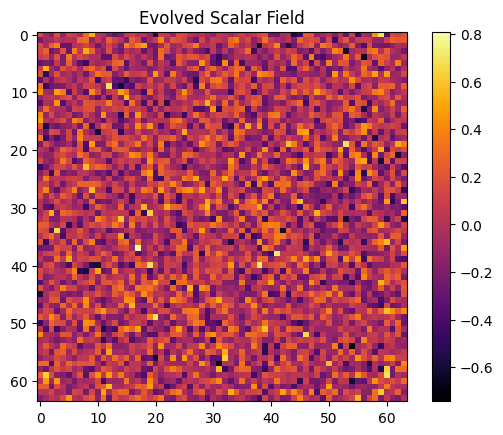

Memory fidelity after 10000 e-folds: 0.0265


In [7]:
field = generate_scalar_field(grid_size, lambda_scalar)
evolved = evolve_scalar_field(field, e_folds)
fidelity = memory_fidelity(field, evolved)

plt.imshow(evolved, cmap='inferno')
plt.title("Evolved Scalar Field")
plt.colorbar()
plt.show()

print(f"Memory fidelity after {e_folds} e-folds: {fidelity:.4f}")
